install libraries

In [1]:
!pip install xgboost
!pip install lightgbm
!pip install mlflow
!pip install optuna
!pip install -q kaggle kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

configure kaggle credetntials

In [2]:
import os
import json

KAGGLE_USERNAME = 'mariamkapanadze'
KAGGLE_API_KEY = 'KGAT_cd47955638de00296ee00cc490a5d931'

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True);

kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')
kaggle_config = {"username": KAGGLE_USERNAME, "key": KAGGLE_API_KEY}

with open(kaggle_json_path, 'w') as f:
    json.dump(kaggle_config, f)

os.chmod(kaggle_json_path, 0o600)
!cat ~/.kaggle/kaggle.json

!pip install -q kagglehub
import kagglehub
kagglehub.login()



{"username": "mariamkapanadze", "key": "KGAT_cd47955638de00296ee00cc490a5d931"}

Kaggle credentials set.
Kaggle credentials successfully validated.


download competition

In [3]:
path = kagglehub.competition_download(
    "walmart-recruiting-store-sales-forecasting"
)

print(path)

100%|██████████| 2.70M/2.70M [00:01<00:00, 2.31MB/s]

Extracting files...
/root/.cache/kagglehub/competitions/walmart-recruiting-store-sales-forecasting


load csv files

In [4]:
import zipfile
import os

for file in os.listdir(path):
    if file.endswith(".zip"):
        file_path = os.path.join(path, file)

        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(path)

print(os.listdir(path))

['test.csv.zip', 'train.csv', 'train.csv.zip', 'sampleSubmission.csv', 'test.csv', 'stores.csv', 'sampleSubmission.csv.zip', 'features.csv.zip', 'features.csv']


In [5]:
import pandas as pd

train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))
features = pd.read_csv(os.path.join(path, "features.csv"))
stores = pd.read_csv(os.path.join(path, "stores.csv"))
submission = pd.read_csv(os.path.join(path, "sampleSubmission.csv"))

In [6]:
print(train.shape)
print(test.shape)
print(stores.shape)
print(features.shape)

(421570, 5)
(115064, 4)
(45, 3)
(8190, 12)


merge datesets

In [7]:
import pandas as pd

train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])


train_merged = (
    train
    .merge(stores, on="Store", how="left")
    .merge(features, on=["Store", "Date"], how="left")
)

test_merged = (
    test
    .merge(stores, on="Store", how="left")
    .merge(features, on=["Store", "Date"], how="left")
)

In [8]:
train_merged.shape
train_merged.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


sort by time

In [9]:
train_merged = train_merged.sort_values(
    ["Store", "Dept", "Date"]
)

add date features

In [10]:
for df in [train_merged, test_merged]:

    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["week"] = df["Date"].dt.isocalendar().week.astype(int)
    df["dayofweek"] = df["Date"].dt.dayofweek
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

encode tyoe

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_merged["Type"] = le.fit_transform(
    train_merged["Type"]
)

test_merged["Type"] = le.transform(
    test_merged["Type"]
)

lightBGM baseline

In [12]:
train_merged.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'year',
       'month', 'week', 'dayofweek', 'is_weekend'],
      dtype='object')

In [13]:
features_baseline = [
    "Store",
    "Dept",
    "IsHoliday_y",
    "Size",
    "Type",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "year",
    "month",
    "week",
    "dayofweek",
    "is_weekend"
]

X = train_merged[features_baseline]
y = train_merged["Weekly_Sales"]

define wmae and bias metrics

In [14]:
import numpy as np

def wmae(y_true, y_pred, is_holiday):
    """Weighted Mean Absolute Error - the Walmart competition metric.
    Holiday weeks get 5x the weight of non-holiday weeks."""
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

def bias(y_true, y_pred):
    """Mean signed error. Positive = model overpredicts, negative = model underpredicts."""
    return np.mean(y_pred - y_true)

In [15]:
split_date = train_merged["Date"].max() - pd.Timedelta(weeks=31)

train_df = train_merged[
    train_merged["Date"] < split_date
]

val_df = train_merged[
    train_merged["Date"] >= split_date
]

X_train = train_df[features_baseline]
y_train = train_df["Weekly_Sales"]

X_val = val_df[features_baseline]
y_val = val_df["Weekly_Sales"]

train lightgbm baseline

In [16]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013113 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1245
[LightGBM] [Info] Number of data points in the train set: 326856, number of used features: 12
[LightGBM] [Info] Start training from score 16029.343725


LGBMRegressor(n_estimators=300, random_state=42)

evaluate

In [17]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(X_val)

mae = mean_absolute_error(
    y_val,
    preds
)

wmae_baseline = wmae(y_val, preds, val_df["IsHoliday_y"])
bias_baseline = bias(y_val, preds)

print("LightGBM Baseline MAE:", mae)
print("LightGBM Baseline WMAE:", wmae_baseline)
print("LightGBM Baseline Bias:", bias_baseline)

LightGBM Baseline MAE: 3206.3339454664538
LightGBM Baseline WMAE: 3242.6419894645173
LightGBM Baseline Bias: 168.2056915095589


In [18]:
import wandb

wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_baseline"
)

wandb.log({
    "model": "LightGBM",
    "experiment": "baseline",
    "mae": mae,
    "wmae": wmae_baseline,
    "bias": bias_baseline
})

wandb.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mkapa22 (mkapa22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


bias,▁
mae,▁
wmae,▁
bias,168.20569
experiment,baseline
mae,3206.33395
model,LightGBM
wmae,3242.64199


run 2 add lag features

In [19]:
train_merged = train_merged.sort_values(
    ["Store", "Dept", "Date"]
)

for lag in [1, 2, 4, 8, 52]:
    train_merged[f"lag_{lag}"] = (
        train_merged
        .groupby(["Store", "Dept"])["Weekly_Sales"]
        .shift(lag)
    )

train_model = train_merged.dropna()

features

In [20]:
features_run2 = features_baseline + [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "lag_52"
]

X = train_model[features_run2]
y = train_model["Weekly_Sales"]

split

In [21]:
split_date = train_model["Date"].max() - pd.Timedelta(weeks=31)

train_df = train_model[train_model["Date"] < split_date]
val_df = train_model[train_model["Date"] >= split_date]

X_train = train_df[features_run2]
y_train = train_df["Weekly_Sales"]

X_val = val_df[features_run2]
y_val = val_df["Weekly_Sales"]

train

In [22]:
from lightgbm import LGBMRegressor

model_run2 = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model_run2.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002116 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 43840, number of used features: 17
[LightGBM] [Info] Start training from score 18852.285254


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

evaluate

In [23]:
from sklearn.metrics import mean_absolute_error

preds = model_run2.predict(X_val)

mae_run2 = mean_absolute_error(
    y_val,
    preds
)

wmae_run2 = wmae(y_val, preds, val_df["IsHoliday_y"])
bias_run2 = bias(y_val, preds)

print("Run 2 MAE:", mae_run2)
print("Run 2 WMAE:", wmae_run2)
print("Run 2 Bias:", bias_run2)

Run 2 MAE: 1850.7209387588778
Run 2 WMAE: 1928.3617895153568
Run 2 Bias: 695.0564328356315


In [24]:
wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_lag_features"
)

wandb.log({
    "model": "LightGBM",
    "experiment": "lag_features",
    "mae": mae_run2,
    "wmae": wmae_run2,
    "bias": bias_run2
})

wandb.finish()

bias,▁
mae,▁
wmae,▁
bias,695.05643
experiment,lag_features
mae,1850.72094
model,LightGBM
wmae,1928.36179


run 3 rolling features

In [25]:
train_model = train_model.copy()

for window in [4, 8]:
    train_model.loc[:, f"rolling_mean_{window}"] = (
        train_model
        .groupby(["Store", "Dept"])["Weekly_Sales"]
        .shift(1)
        .rolling(window)
        .mean()
    )

train_model = train_model.dropna()

In [26]:
features_run3 = features_run2 + [
    "rolling_mean_4",
    "rolling_mean_8"
]

train run3, use same split

In [27]:
X = train_model[features_run3]
y = train_model["Weekly_Sales"]


split_date = train_model["Date"].max() - pd.Timedelta(weeks=31)

train_df = train_model[
    train_model["Date"] < split_date
]

val_df = train_model[
    train_model["Date"] >= split_date
]


X_train = train_df[features_run3]
y_train = train_df["Weekly_Sales"]

X_val = val_df[features_run3]
y_val = val_df["Weekly_Sales"]

model

In [28]:
model_run3 = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model_run3.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2459
[LightGBM] [Info] Number of data points in the train set: 22682, number of used features: 18
[LightGBM] [Info] Start training from score 17883.087898


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

evaluate

In [29]:
from sklearn.metrics import mean_absolute_error

preds = model_run3.predict(X_val)

mae_run3 = mean_absolute_error(
    y_val,
    preds
)

wmae_run3 = wmae(y_val, preds, val_df["IsHoliday_y"])
bias_run3 = bias(y_val, preds)

print("Run 3 MAE:", mae_run3)
print("Run 3 WMAE:", wmae_run3)
print("Run 3 Bias:", bias_run3)

Run 3 MAE: 1676.918154389252
Run 3 WMAE: 1705.7130356164148
Run 3 Bias: 575.5806701609816


In [30]:
wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_rolling_features"
)

wandb.log({
    "model": "LightGBM",
    "experiment": "lag_plus_rolling_features",
    "mae": mae_run3,
    "wmae": wmae_run3,
    "bias": bias_run3
})

wandb.finish()

bias,▁
mae,▁
wmae,▁
bias,575.58067
experiment,lag_plus_rolling_fea...
mae,1676.91815
model,LightGBM
wmae,1705.71304


run 4 add markdown features

In [31]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

train_model = train_model.copy()

train_model[markdown_cols] = train_model[markdown_cols].fillna(0)

features_run4 = features_run2 + markdown_cols

train

In [32]:
X = train_model[features_run4]
y = train_model["Weekly_Sales"]

split_date = train_model["Date"].max() - pd.Timedelta(weeks=31)

train_df = train_model[train_model["Date"] < split_date]
val_df = train_model[train_model["Date"] >= split_date]

X_train = train_df[features_run4]
y_train = train_df["Weekly_Sales"]

X_val = val_df[features_run4]
y_val = val_df["Weekly_Sales"]

In [33]:
from lightgbm import LGBMRegressor

model_run4 = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model_run4.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error

preds = model_run4.predict(X_val)

mae_run4 = mean_absolute_error(y_val, preds)
wmae_run4 = wmae(y_val, preds, val_df["IsHoliday_y"])
bias_run4 = bias(y_val, preds)

print(mae_run4)
print(wmae_run4)
print(bias_run4)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3174
[LightGBM] [Info] Number of data points in the train set: 22682, number of used features: 21
[LightGBM] [Info] Start training from score 17883.087898
1593.088904053076
1604.4955345254282
331.0589491619302


In [34]:
wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_markdown_features"
)

wandb.log({
    "experiment":"markdown_features",
    "mae":mae_run4,
    "wmae":wmae_run4,
    "bias":bias_run4
})

wandb.finish()

bias,▁
mae,▁
wmae,▁
bias,331.05895
experiment,markdown_features
mae,1593.0889
wmae,1604.49553


run 5 holiday affect

In [35]:
train_model = train_model.copy()

train_model["Dept_Holiday"] = (
    train_model["Dept"] * train_model["IsHoliday_y"]
)

features_run5 = features_run2 + [
    "Dept_Holiday"
]

In [36]:
X = train_model[features_run5]
y = train_model["Weekly_Sales"]

split_date = train_model["Date"].max() - pd.Timedelta(weeks=31)

train_df = train_model[train_model["Date"] < split_date]
val_df = train_model[train_model["Date"] >= split_date]

X_train = train_df[features_run5]
y_train = train_df["Weekly_Sales"]

X_val = val_df[features_run5]
y_val = val_df["Weekly_Sales"]

In [37]:
model_run5 = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model_run5.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005925 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2022
[LightGBM] [Info] Number of data points in the train set: 22682, number of used features: 17
[LightGBM] [Info] Start training from score 17883.087898


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

In [38]:
from sklearn.metrics import mean_absolute_error
preds = model_run5.predict(X_val)

mae_run5 = mean_absolute_error(y_val, preds)
wmae_run5 = wmae(y_val, preds, val_df["IsHoliday_y"])
bias_run5 = bias(y_val, preds)

print(mae_run5)
print(wmae_run5)
print(bias_run5)

1657.4710383643169
1694.1983797875498
504.2500840078341


In [39]:
wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_holiday interaction"
)

wandb.log({
    "experiment":"holiday interaction",
    "mae":mae_run5,
    "wmae":wmae_run5,
    "bias":bias_run5
})

wandb.finish()

bias,▁
mae,▁
wmae,▁
bias,504.25008
experiment,holiday interaction
mae,1657.47104
wmae,1694.19838


run 6 hyperparameter tuning

In [40]:
model_run6 = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=64,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42
)

model_run6.fit(
    X_train,
    y_train
)

from sklearn.metrics import mean_absolute_error
preds = model_run6.predict(X_val)

mae_run6 = mean_absolute_error(y_val, preds)
wmae_run6 = wmae(y_val, preds, val_df["IsHoliday_y"])
bias_run6 = bias(y_val, preds)

print(mae_run6)
print(wmae_run6)
print(bias_run6)

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003300 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2022
[LightGBM] [Info] Number of data points in the train set: 22682, number of used features: 17
[LightGBM] [I

In [41]:
wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_holiday interaction"
)

wandb.log({
    "experiment":"holiday interaction",
    "mae":mae_run6,
    "wmae":wmae_run6,
    "bias":bias_run6
})

wandb.finish()

bias,▁
mae,▁
wmae,▁
bias,653.26983
experiment,holiday interaction
mae,1720.36592
wmae,1756.59819


In [42]:
print(features_run2)
print(len(features_run2))

['Store', 'Dept', 'IsHoliday_y', 'Size', 'Type', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week', 'dayofweek', 'is_weekend', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_52']
19


In [43]:
features_current = features_run2.copy()

In [44]:
X = train_model[features_current]
y = train_model["Weekly_Sales"]

split_date = train_model["Date"].max() - pd.Timedelta(weeks=31)

train_df = train_model[train_model["Date"] < split_date]
val_df = train_model[train_model["Date"] >= split_date]

X_train = train_df[features_current]
y_train = train_df["Weekly_Sales"]

X_val = val_df[features_current]
y_val = val_df["Weekly_Sales"]

In [45]:
model_run7 = LGBMRegressor(
    objective="regression",
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=10,
    random_state=42
)

model_run7.fit(X_train, y_train)

preds = model_run7.predict(X_val)

from sklearn.metrics import mean_absolute_error
mae_run7 = mean_absolute_error(y_val, preds)
wmae_run7 = wmae(y_val, preds, val_df["IsHoliday_y"])
bias_run7 = bias(y_val, preds)

print("Run 7 MAE:", mae_run7)
print("Run 7 WMAE:", wmae_run7)
print("Run 7 Bias:", bias_run7)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1949
[LightGBM] [Info] Number of data points in the train set: 22682, number of used features: 16
[LightGBM] [Info] Start training from score 17883.087898
Run 7 MAE: 1682.4713012616132
Run 7 WMAE: 1707.520532000195
Run 7 Bias: 563.6665033909729


In [46]:
wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_run7"
)

wandb.log({
    "experiment": "lightgbm_tuning_v2",
    "mae": mae_run7,
    "wmae": wmae_run7,
    "bias": bias_run7
})

wandb.finish()

bias,▁
mae,▁
wmae,▁
bias,563.6665
experiment,lightgbm_tuning_v2
mae,1682.4713
wmae,1707.52053


run 8

In [47]:
features_current = features_run2.copy()

X = train_model[features_current]
y = train_model["Weekly_Sales"]

split_date = train_model["Date"].max() - pd.Timedelta(weeks=31)

train_df = train_model[train_model["Date"] < split_date]
val_df = train_model[train_model["Date"] >= split_date]

X_train = train_df[features_current]
y_train = train_df["Weekly_Sales"]

X_val = val_df[features_current]
y_val = val_df["Weekly_Sales"]

In [48]:
model_run8 = LGBMRegressor(
    objective="regression",
    n_estimators=1500,
    learning_rate=0.01,
    num_leaves=31,
    min_child_samples=20,
    random_state=42
)

model_run8.fit(
    X_train,
    y_train
)

preds = model_run8.predict(X_val)

from sklearn.metrics import mean_absolute_error

mae_run8 = mean_absolute_error(
    y_val,
    preds
)
wmae_run8 = wmae(y_val, preds, val_df["IsHoliday_y"])
bias_run8 = bias(y_val, preds)

print("Run 8 MAE:", mae_run8)
print("Run 8 WMAE:", wmae_run8)
print("Run 8 Bias:", bias_run8)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001369 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1949
[LightGBM] [Info] Number of data points in the train set: 22682, number of used features: 16
[LightGBM] [Info] Start training from score 17883.087898
Run 8 MAE: 1626.8773136030609
Run 8 WMAE: 1645.9900278434861
Run 8 Bias: 439.00159108149757


In [49]:
wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_run8_low_learning_rate"
)

wandb.log({
    "experiment": "low_learning_rate",
    "mae": mae_run8,
    "wmae": wmae_run8,
    "bias": bias_run8
})

wandb.finish()

bias,▁
mae,▁
wmae,▁
bias,439.00159
experiment,low_learning_rate
mae,1626.87731
wmae,1645.99003


run 9

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

importance = pd.DataFrame({
    "feature": features_run2,
    "importance": model_run2.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

         feature  importance
18        lag_52        2561
14         lag_1        1865
1           Dept        1485
17         lag_8        1211
16         lag_4        1163
15         lag_2        1153
5    Temperature        1019
11          week         919
7            CPI         842
6     Fuel_Price         820
0          Store         486
3           Size         454
8   Unemployment         422
2    IsHoliday_y         353
10         month         177
9           year          68
4           Type           2
13    is_weekend           0
12     dayofweek           0


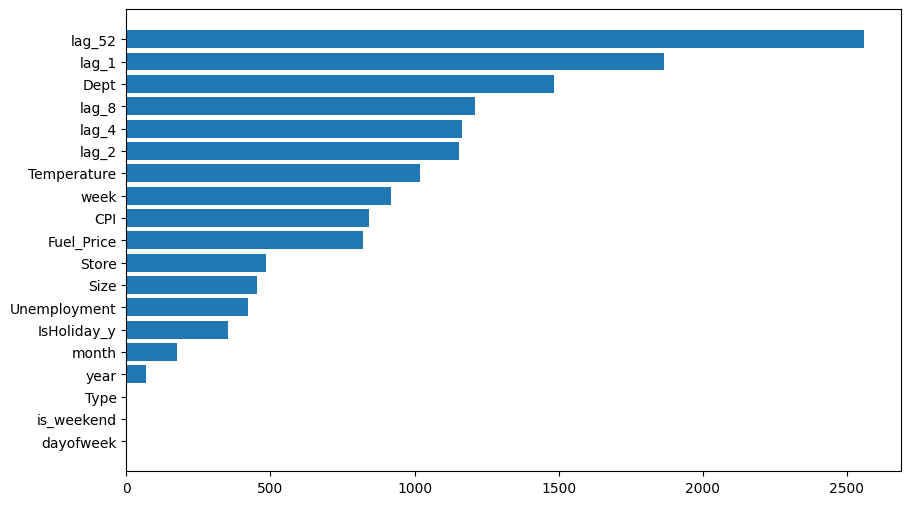

In [51]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.gca().invert_yaxis()
plt.show()

remove weak features

In [52]:
selected_features = importance[
    importance["importance"] > 5
]["feature"].tolist()

print(selected_features)

['lag_52', 'lag_1', 'Dept', 'lag_8', 'lag_4', 'lag_2', 'Temperature', 'week', 'CPI', 'Fuel_Price', 'Store', 'Size', 'Unemployment', 'IsHoliday_y', 'month', 'year']


In [53]:
X = train_model[selected_features]
y = train_model["Weekly_Sales"]

split_date = train_model["Date"].max() - pd.Timedelta(weeks=31)

train_df = train_model[
    train_model["Date"] < split_date
]

val_df = train_model[
    train_model["Date"] >= split_date
]

X_train = train_df[selected_features]
y_train = train_df["Weekly_Sales"]

X_val = val_df[selected_features]
y_val = val_df["Weekly_Sales"]

In [54]:
model_run9 = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model_run9.fit(
    X_train,
    y_train
)

preds = model_run9.predict(X_val)

from sklearn.metrics import mean_absolute_error

mae_run9 = mean_absolute_error(
    y_val,
    preds
)
wmae_run9 = wmae(y_val, preds, val_df["IsHoliday_y"])
bias_run9 = bias(y_val, preds)

print("Run 9 MAE:", mae_run9)
print("Run 9 WMAE:", wmae_run9)
print("Run 9 Bias:", bias_run9)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001020 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1947
[LightGBM] [Info] Number of data points in the train set: 22682, number of used features: 15
[LightGBM] [Info] Start training from score 17883.087898
Run 9 MAE: 1667.6823301213203
Run 9 WMAE: 1694.3384375153903
Run 9 Bias: 519.895822505338


In [55]:
wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_feature_selection"
)

wandb.log({
    "experiment": "feature_selection",
    "mae": mae_run9,
    "wmae": wmae_run9,
    "bias": bias_run9,
    "num_features": len(selected_features)
})

wandb.finish()

bias,▁
mae,▁
num_features,▁
wmae,▁
bias,519.89582
experiment,feature_selection
mae,1667.68233
num_features,16
wmae,1694.33844


run 10

In [56]:
final_lgbm = LGBMRegressor(
    objective="regression",
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

In [57]:
X = train_model[features_run2]
y = train_model["Weekly_Sales"]

split_date = train_model["Date"].max() - pd.Timedelta(weeks=31)

train_df = train_model[
    train_model["Date"] < split_date
]

val_df = train_model[
    train_model["Date"] >= split_date
]

X_train = train_df[features_run2]
y_train = train_df["Weekly_Sales"]

X_val = val_df[features_run2]
y_val = val_df["Weekly_Sales"]

In [58]:
final_lgbm.fit(
    X_train,
    y_train
)

preds = final_lgbm.predict(X_val)

final_mae = mean_absolute_error(
    y_val,
    preds
)
final_wmae = wmae(y_val, preds, val_df["IsHoliday_y"])
final_bias = bias(y_val, preds)

print("Final LightGBM MAE:", final_mae)
print("Final LightGBM WMAE:", final_wmae)
print("Final LightGBM Bias:", final_bias)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1949
[LightGBM] [Info] Number of data points in the train set: 22682, number of used features: 16
[LightGBM] [Info] Start training from score 17883.087898
Final LightGBM MAE: 1617.1650438699278
Final LightGBM WMAE: 1644.235333359389
Final LightGBM Bias: 431.46697541196806


In [59]:
wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_final_model"
)

wandb.log({
    "experiment": "final_lightgbm",
    "mae": final_mae,
    "wmae": final_wmae,
    "bias": final_bias,
    "features": "lag_features",
    "model": "LightGBM"
})

wandb.finish()

bias,▁
mae,▁
wmae,▁
bias,431.46698
experiment,final_lightgbm
features,lag_features
mae,1617.16504
model,LightGBM
wmae,1644.23533


In [60]:
import joblib

joblib.dump(
    model_run2,
    "lightgbm_best_model.pkl"
)

['lightgbm_best_model.pkl']

In [61]:
import os
os.listdir()

['.config', 'lightgbm_best_model.pkl', 'wandb', 'sample_data']

In [62]:
import wandb

run = wandb.init(
    project="walmart-sales-forecasting",
    name="lightgbm_best_model_artifact"
)

artifact = wandb.Artifact(
    "lightgbm-best-model",
    type="model"
)

artifact.add_file(
    "lightgbm_best_model.pkl"
)

run.log_artifact(artifact)

wandb.finish()